# 01 — EDA: application_train / application_test

Análisis exploratorio de la tabla principal, **orientado al target** (probabilidad de default).  
No se incluyen visualizaciones de distribución poblacional general; todo está en función de `TARGET`.

## Contenido
1. CSV → Parquet (una sola vez)
2. Shape, tipos y valores faltantes
3. Distribución del TARGET
4. Detección de anomalías
5. Correlación con TARGET (numéricas)
6. KDE por TARGET — top features numéricas
7. % Default por categoría — variables categóricas y edad en tramos
8. Análisis de EXT_SOURCE (variables más predictivas)
9. Resumen de candidatas a features

In [29]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('white')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

# Paleta TARGET
COLOR_0 = "#000986"   # azul → no default
COLOR_1 = "#fc1c03"   # rojo → default

# Rutas
ROOT       = os.path.abspath(os.path.join('..', '..'))
DATA_RAW   = os.path.join(ROOT, 'data', 'raw')
DATA_PROC  = os.path.join(ROOT, 'data', 'processed')

os.makedirs(DATA_PROC, exist_ok=True)

print(f'RAW : {DATA_RAW}')
print(f'PROC: {DATA_PROC}')

RAW : c:\Users\HP\OneDrive\Escritorio\David Guzzi\Github\MECMT07\data\raw
PROC: c:\Users\HP\OneDrive\Escritorio\David Guzzi\Github\MECMT07\data\processed


## 1. CSV → Parquet
Solo se ejecuta si el parquet no existe todavía.

In [30]:
TRAIN_PARQ = os.path.join(DATA_PROC, 'app_train.parquet')
TEST_PARQ  = os.path.join(DATA_PROC, 'app_test.parquet')

if not os.path.exists(TRAIN_PARQ):
    print('Convirtiendo application_train.csv → parquet ...')
    df = pd.read_csv(os.path.join(DATA_RAW, 'application_train.csv'))
    df.to_parquet(TRAIN_PARQ, index=False)
    print(f'  Guardado: {TRAIN_PARQ}')
else:
    print('app_train.parquet ya existe — saltando conversión.')

if not os.path.exists(TEST_PARQ):
    print('Convirtiendo application_test.csv → parquet ...')
    df_test = pd.read_csv(os.path.join(DATA_RAW, 'application_test.csv'))
    df_test.to_parquet(TEST_PARQ, index=False)
    print(f'  Guardado: {TEST_PARQ}')
else:
    print('app_test.parquet ya existe — saltando conversión.')

Convirtiendo application_train.csv → parquet ...
  Guardado: c:\Users\HP\OneDrive\Escritorio\David Guzzi\Github\MECMT07\data\processed\app_train.parquet
Convirtiendo application_test.csv → parquet ...
  Guardado: c:\Users\HP\OneDrive\Escritorio\David Guzzi\Github\MECMT07\data\processed\app_test.parquet


## 2. Carga y estructura

In [31]:
train = pd.read_parquet(TRAIN_PARQ)
test  = pd.read_parquet(TEST_PARQ)

print(f'Train: {train.shape[0]:,} filas × {train.shape[1]} columnas')
print(f'Test : {test.shape[0]:,} filas × {test.shape[1]} columnas')

# Tipos de variables
dtypes = train.dtypes.value_counts()
print(f'\nTipos en train: {dict(dtypes)}')

# Columnas numéricas y categóricas
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = train.select_dtypes(include='object').columns.tolist()
print(f'Numéricas: {len(num_cols)} | Categóricas: {len(cat_cols)}')

Train: 307,511 filas × 122 columnas
Test : 48,744 filas × 121 columnas

Tipos en train: {dtype('float64'): np.int64(65), dtype('int64'): np.int64(41), dtype('O'): np.int64(16)}
Numéricas: 106 | Categóricas: 16


In [32]:
# Tabla de valores faltantes — ordenada por % NA descendente
miss = train.isnull().sum()
miss_pct = (miss / len(train) * 100).round(2)
miss_df = pd.DataFrame({'NA_count': miss, 'NA_pct': miss_pct})
miss_df = miss_df[miss_df['NA_count'] > 0].sort_values('NA_pct', ascending=False)

print(f'Columnas con NA: {len(miss_df)} de {train.shape[1]}')
print(f'Columnas con >50% NA: {(miss_df.NA_pct > 50).sum()}')
print(f'Columnas con >90% NA: {(miss_df.NA_pct > 90).sum()}')
display(miss_df.head(20))

Columnas con NA: 67 de 122
Columnas con >50% NA: 41
Columnas con >90% NA: 0


,NA_count,NA_pct
COMMONAREA_MEDI,214865,69.87
COMMONAREA_MODE,214865,69.87
COMMONAREA_AVG,214865,69.87
NONLIVINGAPARTMENTS_MODE,213514,69.43
NONLIVINGAPARTMENTS_MEDI,213514,69.43
NONLIVINGAPARTMENTS_AVG,213514,69.43
FONDKAPREMONT_MODE,210295,68.39
LIVINGAPARTMENTS_AVG,210199,68.35
LIVINGAPARTMENTS_MEDI,210199,68.35
LIVINGAPARTMENTS_MODE,210199,68.35


## 3. Distribución del TARGET

TARGET  |  N        |  %
  0 (paga)    |  282,686 |  91.9%
  1 (default) |   24,825 |   8.1%


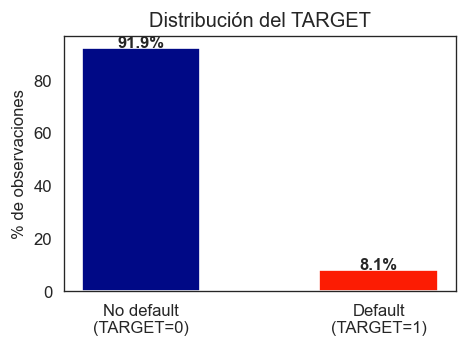

In [33]:
vc = train['TARGET'].value_counts()
pct = train['TARGET'].value_counts(normalize=True) * 100

print('TARGET  |  N        |  %')
print(f'  0 (paga)    | {vc[0]:>8,} | {pct[0]:>5.1f}%')
print(f'  1 (default) | {vc[1]:>8,} | {pct[1]:>5.1f}%')

fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(['No default\n(TARGET=0)', 'Default\n(TARGET=1)'],
       [pct[0], pct[1]],
       color=[COLOR_0, COLOR_1], edgecolor='white', width=0.5)
ax.set_ylabel('% de observaciones')
ax.set_title('Distribución del TARGET')
for i, v in enumerate([pct[0], pct[1]]):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Detección de anomalías

In [34]:
# DAYS_EMPLOYED = 365243 → valor especial que indica 'no empleado'
#
# Origen: 365243 / 365 ≈ 1000 años de antigüedad laboral → imposible.
# Este valor es un placeholder documentado en el foro oficial de la competencia
# para perfiles sin empleo formal: jubilados, amas de casa, estudiantes, desempleados.
#
# Confirmación empírica (ver abajo): la tasa de default de este grupo (5.4%) es
# notablemente menor que la del resto (8.7%) → comportamiento diferente →
# en feature engineering se tratará como flag binaria (DAYS_EMPLOYED_ANOM = 1).

anom_mask = train['DAYS_EMPLOYED'] == 365243
print(f'DAYS_EMPLOYED == 365243: {anom_mask.sum():,} casos ({anom_mask.mean()*100:.1f}%)')
print(f'  Default rate con anomalía : {train.loc[anom_mask, "TARGET"].mean()*100:.1f}%')
print(f'  Default rate sin anomalía : {train.loc[~anom_mask, "TARGET"].mean()*100:.1f}%')

# DAYS_BIRTH — verificar rango (debe ser negativo, en días desde hoy)
print(f'\nDAYS_BIRTH: min={train["DAYS_BIRTH"].min()}, max={train["DAYS_BIRTH"].max()}')
print(f'  → Edades: {(-train["DAYS_BIRTH"]/365).min():.0f}–{(-train["DAYS_BIRTH"]/365).max():.0f} años')

# CODE_GENDER XNA
print(f'\nCODE_GENDER distribución:')
print(train['CODE_GENDER'].value_counts())

DAYS_EMPLOYED == 365243: 55,374 casos (18.0%)
  Default rate con anomalía : 5.4%
  Default rate sin anomalía : 8.7%

DAYS_BIRTH: min=-25229, max=-7489
  → Edades: 21–69 años

CODE_GENDER distribución:
CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64


## 5. Correlación con TARGET (variables numéricas)

In [35]:
# Excluir SK_ID_CURR (ID aleatorio — sin información predictiva) y TARGET del cómputo.
# Las variables binarias FLAG_* son válidas: Pearson con variable dicotómica = correlación
# punto-biserial, estadísticamente correcta para medir asociación con el TARGET.
exclude_from_corr = {'SK_ID_CURR', 'TARGET'}
num_cols_corr = [c for c in num_cols if c not in exclude_from_corr]

corr_target = train[num_cols_corr].corrwith(train['TARGET'])

# Clasificar tipo de variable para transparencia
def classify_var(col):
    if col.startswith('FLAG_') or col in {'NFLAG_INSURED_ON_APPROVAL'}:
        return 'binary_flag'
    elif col.startswith('AMT_REQ_CREDIT_BUREAU'):
        return 'count'
    elif col.startswith('CNT_'):
        return 'count'
    else:
        return 'continuous'

corr_df = pd.DataFrame({
    'feature':  corr_target.index,
    'corr':     corr_target.values,
    'abs_corr': corr_target.abs().values,
    'var_type': [classify_var(c) for c in corr_target.index],
}).sort_values('abs_corr', ascending=False)

print('Top 20 variables numéricas más correlacionadas con TARGET:')
print('(FLAG_* binarias: correlación punto-biserial — estadísticamente válida)')
display(corr_df.head(20)[['feature', 'var_type', 'corr']].reset_index(drop=True))

Top 20 variables numéricas más correlacionadas con TARGET:
(FLAG_* binarias: correlación punto-biserial — estadísticamente válida)


,feature,var_type,corr
0,EXT_SOURCE_3,continuous,-0.178919
1,EXT_SOURCE_2,continuous,-0.160472
2,EXT_SOURCE_1,continuous,-0.155317
3,DAYS_BIRTH,continuous,0.078239
4,REGION_RATING_CLIENT_W_CITY,continuous,0.060893
5,REGION_RATING_CLIENT,continuous,0.058899
6,DAYS_LAST_PHONE_CHANGE,continuous,0.055218
7,DAYS_ID_PUBLISH,continuous,0.051457
8,REG_CITY_NOT_WORK_CITY,continuous,0.050994
9,FLAG_EMP_PHONE,binary_flag,0.045982


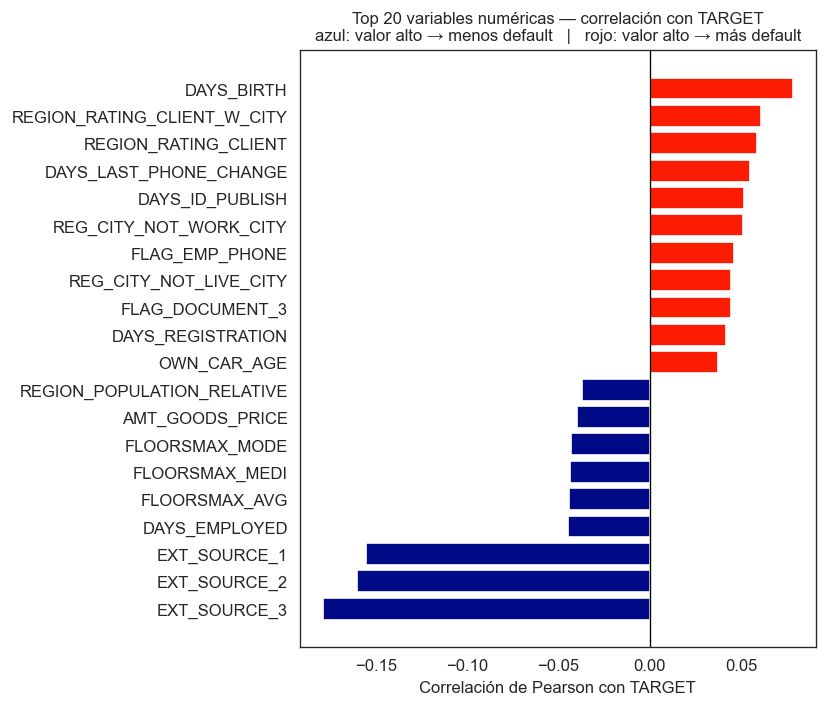

In [36]:
# Ordenar por valor raw (más negativo → más positivo):
#   Azul (corr < 0): valor alto de la variable → MENOS default
#   Rojo (corr > 0): valor alto de la variable → MÁS default
# Tomar top 20 por |corr| y luego ordenarlos por valor raw para el gradiente visual.
top20 = corr_df.head(20).sort_values('corr', ascending=True)

fig, ax = plt.subplots(figsize=(7, 6))
colors = [COLOR_0 if c < 0 else COLOR_1 for c in top20['corr']]
ax.barh(top20['feature'], top20['corr'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlación de Pearson con TARGET')
ax.set_title(
    'Top 20 variables numéricas — correlación con TARGET\n'
    'azul: valor alto → menos default   |   rojo: valor alto → más default',
    fontsize=10
)
plt.tight_layout()
plt.show()

## 6. KDE por TARGET — top variables numéricas

Para cada feature, se superponen las distribuciones de TARGET=0 y TARGET=1.  
Una separación visual clara indica poder predictivo.

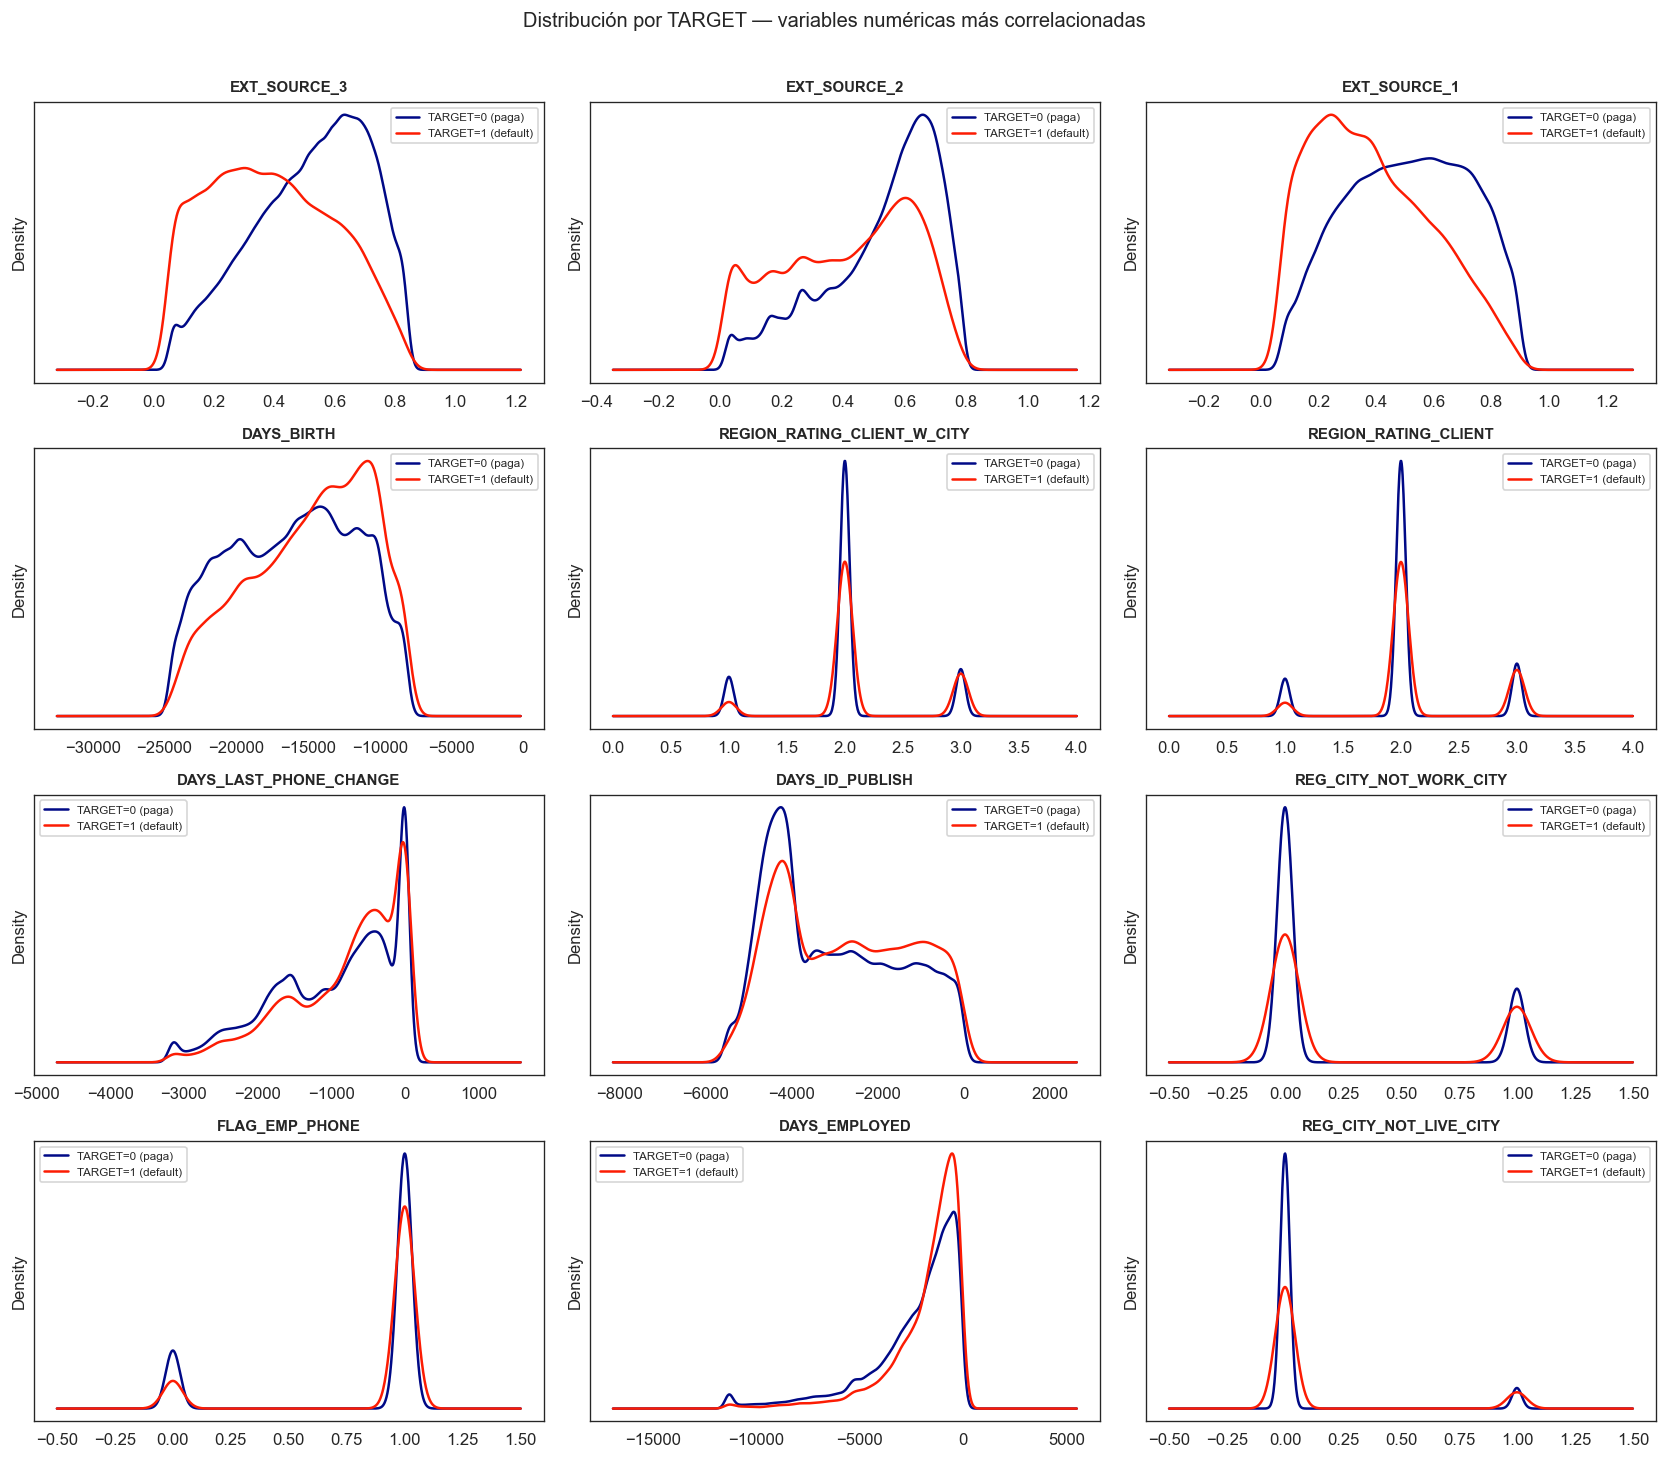

In [37]:
# Features numéricas a graficar (top 12 por |correlación|)
top_num = corr_df.head(12)['feature'].tolist()

# Para DAYS_EMPLOYED: reemplazar el valor anómalo 365243 con NaN antes de graficar.
# Si no se hace, el clip al percentil 99 puede quedar sesgado por los 55k casos anómalos.
train_plot = train.copy()
if 'DAYS_EMPLOYED' in train_plot.columns:
    train_plot['DAYS_EMPLOYED'] = train_plot['DAYS_EMPLOYED'].replace(365243, np.nan)

df0 = train_plot[train_plot['TARGET'] == 0]
df1 = train_plot[train_plot['TARGET'] == 1]

fig, axes = plt.subplots(4, 3, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(top_num):
    ax = axes[i]
    lo = train_plot[col].quantile(0.01)
    hi = train_plot[col].quantile(0.99)
    s0 = df0[col].clip(lo, hi).dropna()
    s1 = df1[col].clip(lo, hi).dropna()

    s0.plot.kde(ax=ax, color=COLOR_0, label='TARGET=0 (paga)', linewidth=1.5)
    s1.plot.kde(ax=ax, color=COLOR_1, label='TARGET=1 (default)', linewidth=1.5)
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=7)
    ax.set_yticks([])

plt.suptitle('Distribución por TARGET — variables numéricas más correlacionadas',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 7. % Default por categoría — variables categóricas

Para cada variable categórica: tasa de default por categoría (no conteos absolutos).  
La línea roja punteada indica la tasa global de default (8.1%).

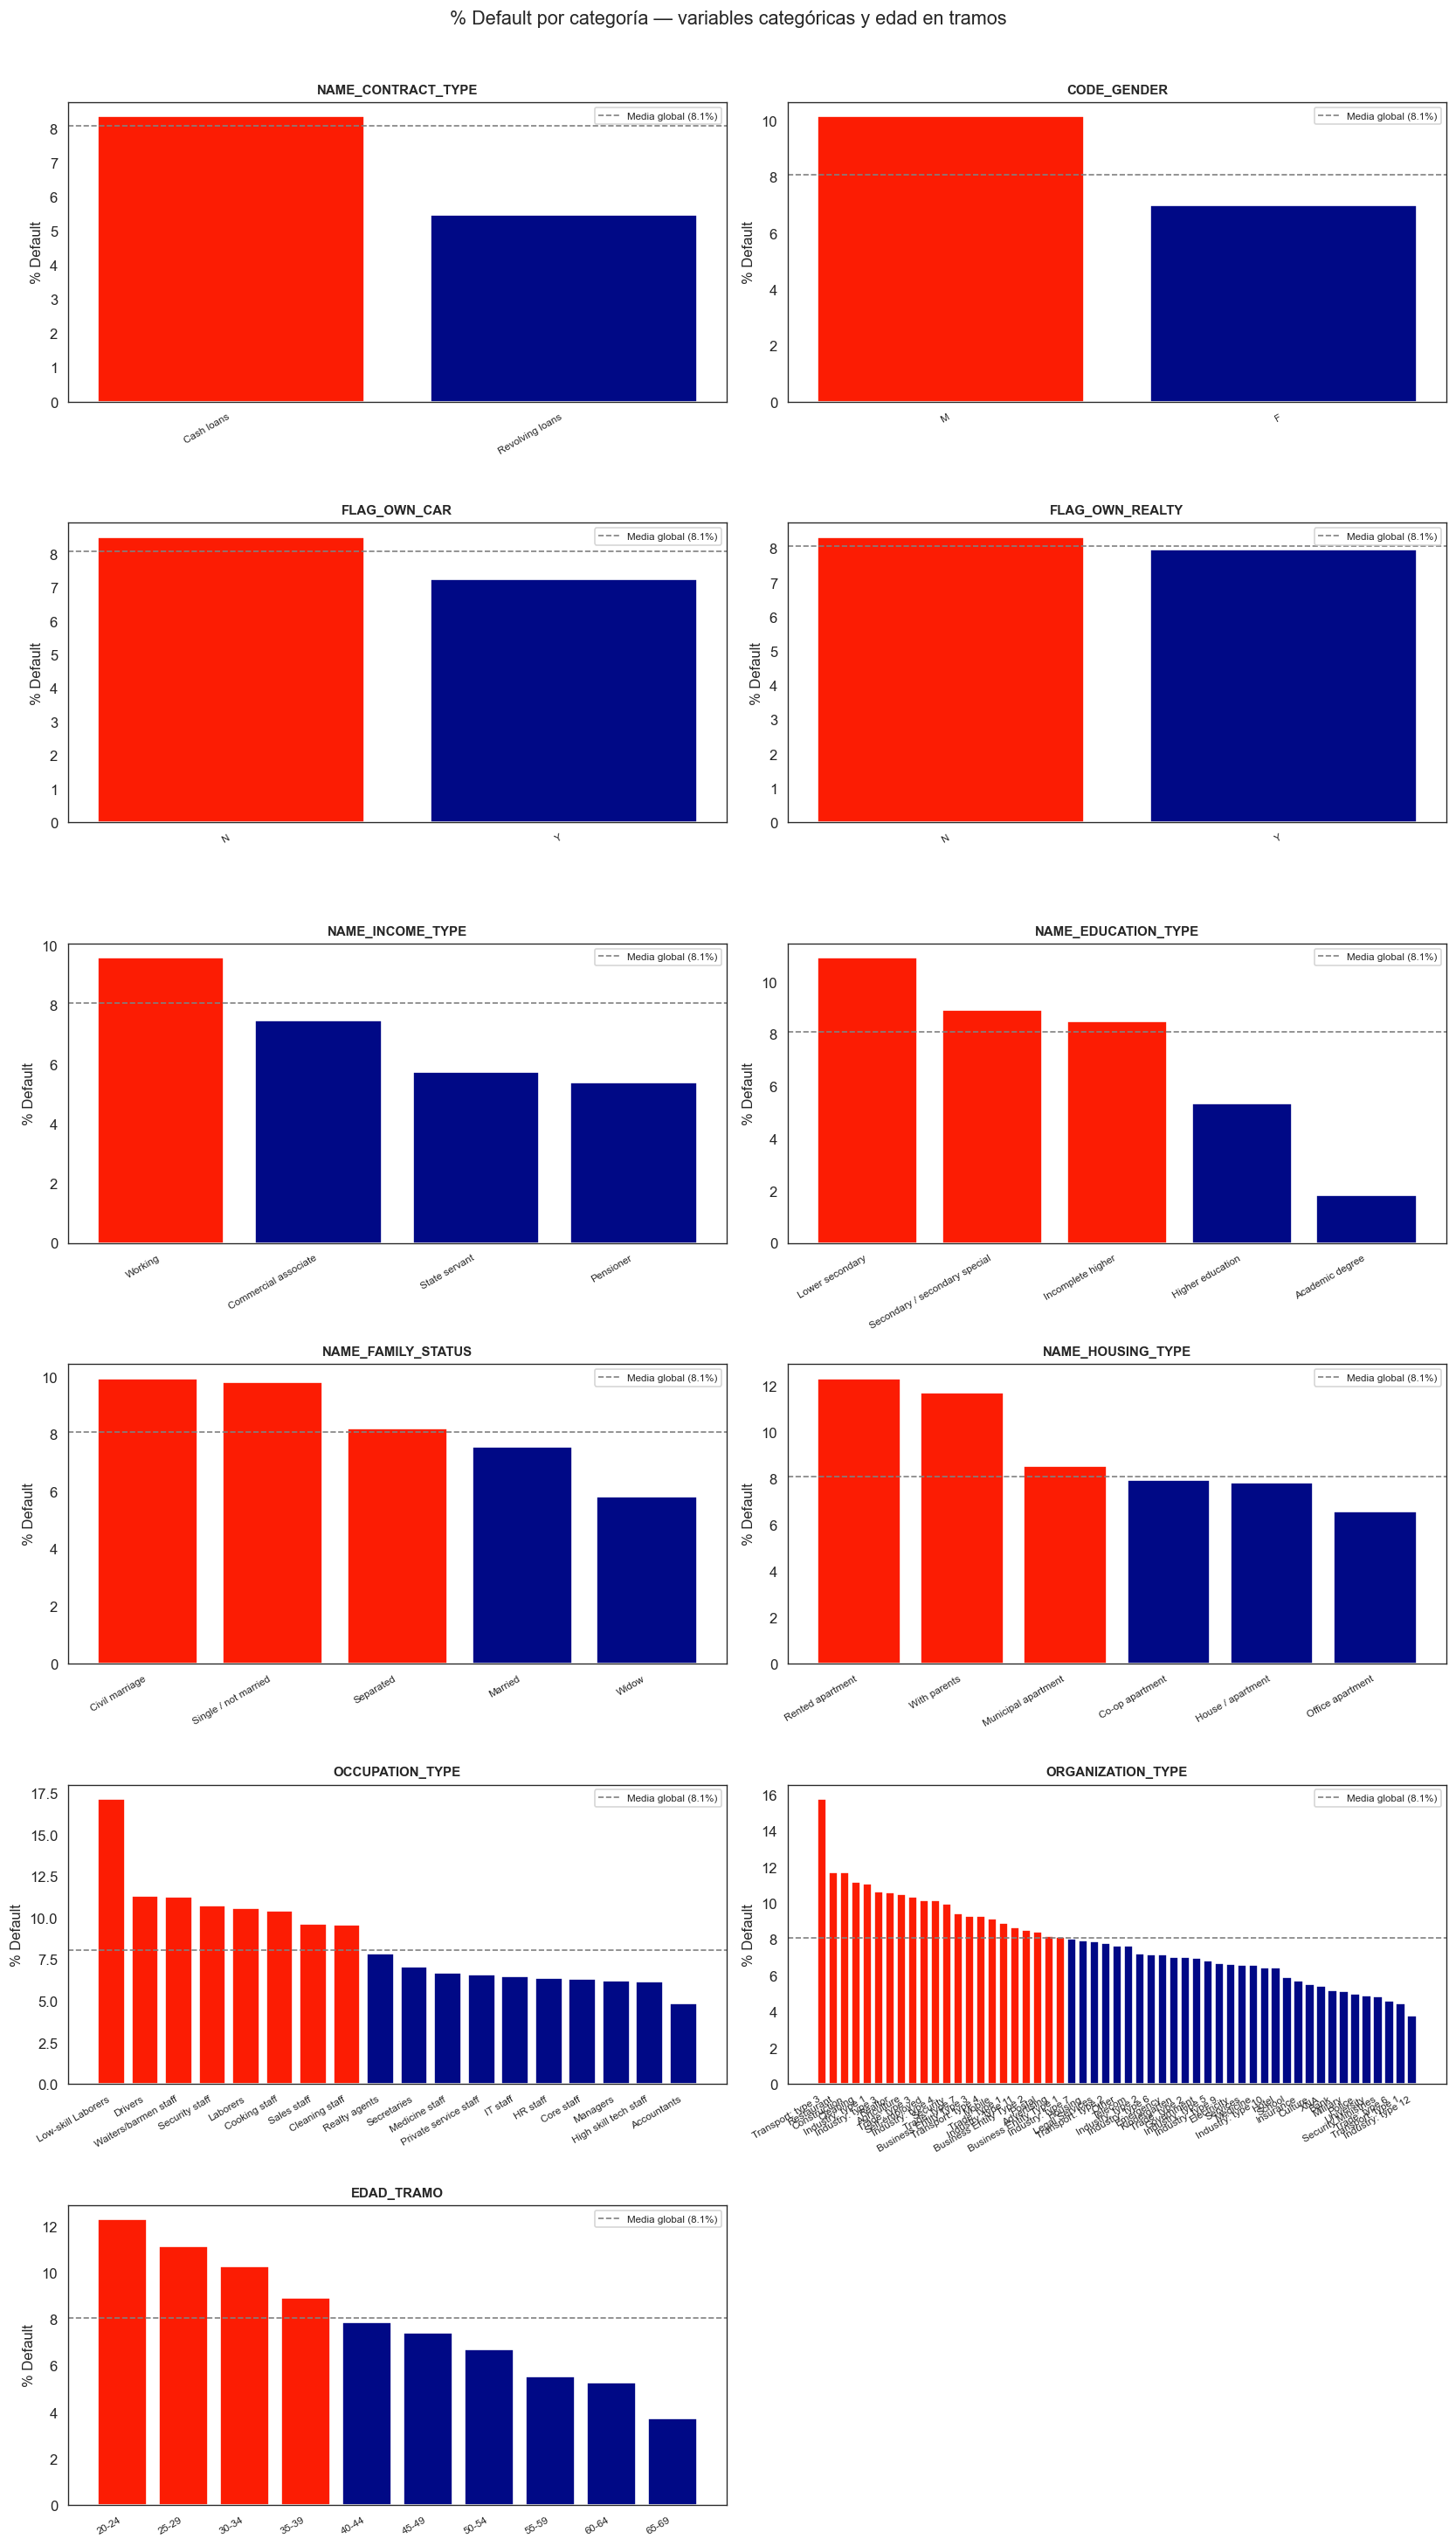

In [38]:
global_rate = train['TARGET'].mean()

def plot_cat_default_rate(df, col, ax):
    """Barra de % default por categoría, ordenada de mayor a menor."""
    stats = df.groupby(col, observed=True)['TARGET'].agg(['mean', 'count'])
    stats = stats.sort_values('mean', ascending=False)
    stats['mean_pct'] = stats['mean'] * 100
    stats = stats[stats['count'] >= 100]

    colors = [COLOR_1 if v > global_rate else COLOR_0 for v in stats['mean']]
    ax.bar(range(len(stats)), stats['mean_pct'], color=colors, edgecolor='white')
    ax.axhline(global_rate * 100, color='gray', linestyle='--', linewidth=1,
               label=f'Media global ({global_rate*100:.1f}%)')
    ax.set_xticks(range(len(stats)))
    ax.set_xticklabels(stats.index, rotation=30, ha='right', fontsize=7)
    ax.set_ylabel('% Default')
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.legend(fontsize=7)
    return stats

# Variables categóricas estándar
cat_to_plot = [
    'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
    'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE'
]
cat_to_plot = [c for c in cat_to_plot if c in train.columns]

# Agregar DAYS_BIRTH en tramos de 5 años (pseudo-categórica: mismo formato de análisis)
train_cat = train.copy()
train_cat['EDAD_TRAMO'] = pd.cut(
    (-train_cat['DAYS_BIRTH'] / 365).astype(int),
    bins=list(range(20, 75, 5)),
    right=False,
    labels=[f'{a}-{a+4}' for a in range(20, 70, 5)]
)
cat_to_plot_ext = cat_to_plot + ['EDAD_TRAMO']

n_plots = len(cat_to_plot_ext)
nrows = (n_plots + 1) // 2

fig, axes = plt.subplots(nrows, 2, figsize=(14, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_to_plot_ext):
    df_plot = train_cat if col == 'EDAD_TRAMO' else train
    plot_cat_default_rate(df_plot, col, axes[i])

# Ocultar ejes sobrantes
for j in range(len(cat_to_plot_ext), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('% Default por categoría — variables categóricas y edad en tramos',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 8. Análisis de EXT_SOURCE (variables más predictivas)

`EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3` son scores externos de riesgo crediticio.  
Son consistentemente las variables más correlacionadas con el TARGET en esta competencia.

EXT_SOURCE — estadísticas por TARGET:

EXT_SOURCE_1  (NA: 56.4%,  corr con TARGET: -0.1553)


,mean,median,std
TARGET,,,
0,0.511461,0.517452,0.208804
1,0.386968,0.361675,0.204729



EXT_SOURCE_2  (NA: 0.2%,  corr con TARGET: -0.1605)


,mean,median,std
TARGET,,,
0,0.523479,0.573905,0.186277
1,0.410935,0.440381,0.213107



EXT_SOURCE_3  (NA: 19.8%,  corr con TARGET: -0.1789)


,mean,median,std
TARGET,,,
0,0.520969,0.546023,0.190465
1,0.390717,0.379100,0.205810


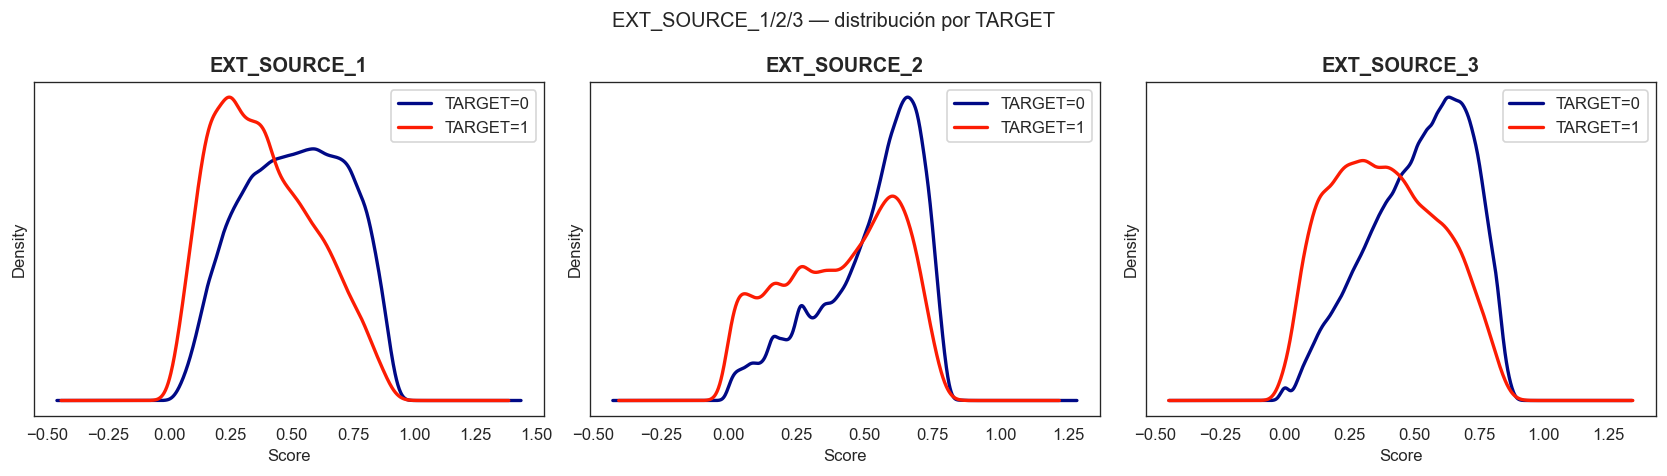

In [39]:
ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

print('EXT_SOURCE — estadísticas por TARGET:')
for col in ext_cols:
    if col in train.columns:
        stats = train.groupby('TARGET')[col].agg(['mean', 'median', 'std'])
        corr_val = train[col].corr(train['TARGET'])
        na_pct = train[col].isnull().mean() * 100
        print(f'\n{col}  (NA: {na_pct:.1f}%,  corr con TARGET: {corr_val:.4f})')
        display(stats)

# KDE combinado de los 3 EXT_SOURCE
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, col in enumerate(ext_cols):
    if col in train.columns:
        ax = axes[i]
        for target_val, color, label in [(0, COLOR_0, 'TARGET=0'), (1, COLOR_1, 'TARGET=1')]:
            s = train.loc[train['TARGET'] == target_val, col].dropna()
            s.plot.kde(ax=ax, color=color, label=label, linewidth=2)
        ax.set_title(col, fontweight='bold')
        ax.set_xlabel('Score')
        ax.set_yticks([])
        ax.legend()

plt.suptitle('EXT_SOURCE_1/2/3 — distribución por TARGET', fontsize=12)
plt.tight_layout()
plt.show()

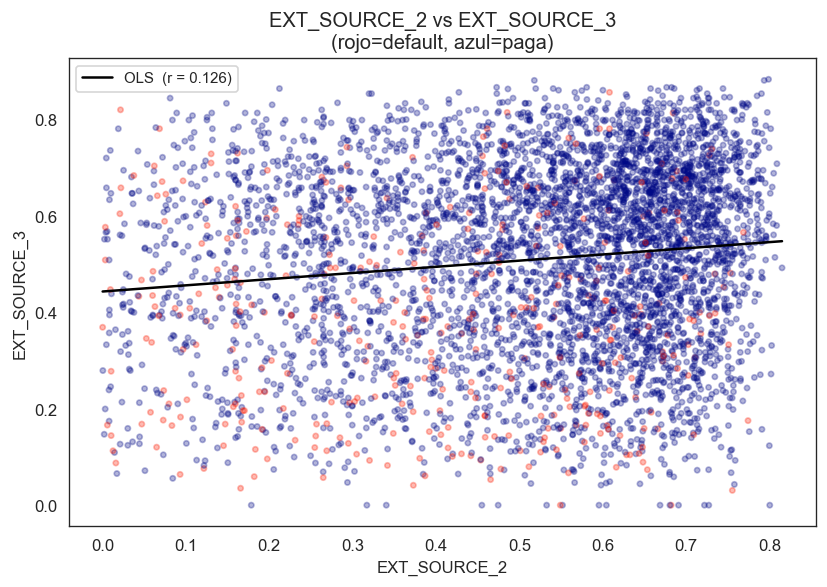

In [40]:
# Scatter EXT_SOURCE_2 vs EXT_SOURCE_3 con:
# - puntos coloreados por TARGET
# - línea OLS para mostrar la tendencia lineal entre ambas variables
# - anotación r = correlación entre EXT_SOURCE_2 y EXT_SOURCE_3
#   (relevante para evaluar multicolinealidad en los modelos)

sample = train.dropna(subset=['EXT_SOURCE_2', 'EXT_SOURCE_3']).sample(5000, random_state=42)

r_23 = sample['EXT_SOURCE_2'].corr(sample['EXT_SOURCE_3'])
m, b_ols = np.polyfit(sample['EXT_SOURCE_2'], sample['EXT_SOURCE_3'], 1)
x_line = np.linspace(sample['EXT_SOURCE_2'].min(), sample['EXT_SOURCE_2'].max(), 100)
y_line = m * x_line + b_ols

fig, ax = plt.subplots(figsize=(7, 5))
scatter_colors = [COLOR_1 if t == 1 else COLOR_0 for t in sample['TARGET']]
ax.scatter(sample['EXT_SOURCE_2'], sample['EXT_SOURCE_3'],
           c=scatter_colors, alpha=0.3, s=10,
           label='_nolegend_')
ax.plot(x_line, y_line, color='black', linewidth=1.5, label=f'OLS  (r = {r_23:.3f})')
ax.set_xlabel('EXT_SOURCE_2')
ax.set_ylabel('EXT_SOURCE_3')
ax.set_title('EXT_SOURCE_2 vs EXT_SOURCE_3\n(rojo=default, azul=paga)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 10. Resumen — candidatas a features

Variables de `application_train` seleccionadas para el notebook de feature engineering (05):

In [ ]:
print('Features seleccionadas de application_train para notebook 05:')
selected = [
    ('EXT_SOURCE_3',                'Score de riesgo externo (bureau 3); el más predictivo (corr -0.18)'),
    ('EXT_SOURCE_2',                'Score de riesgo externo (bureau 2); el más completo (solo 0.2% NA)'),
    ('EXT_SOURCE_1',                'Score de riesgo externo (bureau 1); valores altos = menor riesgo'),
    ('DAYS_BIRTH',                  'Edad en días desde la solicitud (negativo); mayor edad → menos default'),
    ('REGION_RATING_CLIENT_W_CITY', 'Rating crediticio de la región del cliente (1=mejor, 3=peor)'),
    ('DAYS_ID_PUBLISH',             'Días desde la última renovación del documento de identidad'),
    ('DAYS_EMPLOYED',               'Días de antigüedad laboral (negativo); 365243 = sin empleo formal'),
    ('FLAG_DOCUMENT_3',             'Presentó documento tipo 3 (1=sí); el flag documental más predictivo'),
    ('DAYS_REGISTRATION',           'Días desde el último cambio de domicilio registrado'),
    ('AMT_GOODS_PRICE',             'Precio del bien financiado; montos mayores → menos default'),
    ('OWN_CAR_AGE',                 'Antigüedad del auto propio en años (NaN si no tiene auto)'),
    ('AMT_CREDIT',                  'Monto total del crédito solicitado'),
    ('AMT_ANNUITY',                 'Cuota mensual del crédito; bajo poder predictivo en forma aislada'),
    ('CNT_FAM_MEMBERS',             'Cantidad de miembros del grupo familiar'),
    ('AMT_INCOME_TOTAL',            'Ingreso total declarado; bajo poder predictivo en forma aislada'),
]
for feat, desc in selected:
    corr_val = corr_target.get(feat, None)
    if corr_val is not None:
        print(f'  {feat:<35s} corr={corr_val:+.4f}  ← {desc}')
    else:
        print(f'  {feat:<35s}  ← {desc}')

print('\nFeatures engineered a crear en 05_feature_engineering:')
engineered = [
    ('DAYS_EMPLOYED_PERCENT', 'DAYS_EMPLOYED / DAYS_BIRTH',          'Fracción de la vida activa trabajada (estabilidad laboral)'),
    ('DAYS_EMPLOYED_ANOM',    '1 si DAYS_EMPLOYED == 365243',        'Flag de perfil sin empleo formal (jubilado/ama de casa/desempleado)'),
    ('ANNUITY_INCOME_RATIO',  'AMT_ANNUITY / AMT_INCOME_TOTAL',     'Carga de la cuota sobre el ingreso (estrés financiero mensual)'),
    ('CREDIT_INCOME_RATIO',   'AMT_CREDIT / AMT_INCOME_TOTAL',      'Deuda total en relación al ingreso anual'),
    ('CREDIT_ANNUITY_RATIO',  'AMT_CREDIT / AMT_ANNUITY',           'Plazo implícito del crédito (≈ meses = crédito/cuota)'),
    ('CREDIT_GOODS_RATIO',    'AMT_CREDIT / AMT_GOODS_PRICE',       'Fracción del bien que se financia (1.0 = cubre el precio total)'),
    ('INCOME_PER_PERSON',     'AMT_INCOME_TOTAL / CNT_FAM_MEMBERS', 'Ingreso disponible per cápita familiar'),
]
for name, formula, desc in engineered:
    print(f'  {name:<25s} = {formula:<35s} ← {desc}')

---
**Próximo notebook**: `02_eda_bureau.ipynb` — historial crediticio en otras instituciones.